In [1]:
## import libs
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
import numpy as np

In [2]:
df = pd.read_csv('BA_reviews.csv')
df

,Unnamed: 0,reviews
0,0,✅ Trip Verified | We are extremely grateful ...
1,1,✅ Trip Verified | I had an appalling experie...
2,2,"Not Verified | Good points, the cabin crew, t..."
3,3,"Not Verified | It was a decent flight, reason..."
4,4,✅ Trip Verified | I really like flying Briti...
...,...,...
2995,2995,Great flight with BA - departure at Milan was ...
2996,2996,My wife and I flew from Toronto to London (ret...
2997,2997,I didn't really know what to expect from this ...
2998,2998,Given BA's bizarre and relentless assault on i...


In [3]:
df.shape

(3000, 2)

In [4]:
df.info

<bound method DataFrame.info of       Unnamed: 0                                            reviews
0              0  ✅ Trip Verified |   We are extremely grateful ...
1              1  ✅ Trip Verified |   I had an appalling experie...
2              2  Not Verified |  Good points, the cabin crew, t...
3              3  Not Verified |  It was a decent flight, reason...
4              4  ✅ Trip Verified |   I really like flying Briti...
...          ...                                                ...
2995        2995  Great flight with BA - departure at Milan was ...
2996        2996  My wife and I flew from Toronto to London (ret...
2997        2997  I didn't really know what to expect from this ...
2998        2998  Given BA's bizarre and relentless assault on i...
2999        2999  London to Miami return. Flew out with 5 childr...

[3000 rows x 2 columns]>

In [5]:
df = df.drop('Unnamed: 0',axis = 1)

In [6]:
df.head()

,reviews
0,✅ Trip Verified | We are extremely grateful ...
1,✅ Trip Verified | I had an appalling experie...
2,"Not Verified | Good points, the cabin crew, t..."
3,"Not Verified | It was a decent flight, reason..."
4,✅ Trip Verified | I really like flying Briti...


In [7]:
import re
from sklearn.feature_extraction.text import ENGLISH_STOP_WORDS #built in stopwords

In [8]:
stop_words = ENGLISH_STOP_WORDS #list of useless words

In [9]:
def clean_text(text):
    text = str(text).lower()
    text = text.replace('trip verified', '')          # remove "Trip verified"
    text = text.replace('not verified', '')           # remove "Not Verified"
    text = re.sub(r'[^a-z\s]', '', text)              # remove punctuation/numbers
    text = re.sub(r'\s+', ' ', text).strip()          # remove extra spaces
    tokens = text.split()
    tokens = [w for w in tokens if w not in stop_words and len(w) > 2]
    return ' '.join(tokens)


In [10]:
df["cleaned"] = df["reviews"].astype(str).apply(clean_text)
df[["reviews", "cleaned"]].head()

,reviews,cleaned
0,✅ Trip Verified | We are extremely grateful ...,extremely grateful crew flight cape town heath...
1,✅ Trip Verified | I had an appalling experie...,appalling experience british airways started t...
2,"Not Verified | Good points, the cabin crew, t...",good points cabin crew helpful professional ma...
3,"Not Verified | It was a decent flight, reason...",decent flight reasonable comfortable seat pilo...
4,✅ Trip Verified | I really like flying Briti...,really like flying british airways particularl...


In [11]:
from vaderSentiment.vaderSentiment import SentimentIntensityAnalyzer
analyzer = SentimentIntensityAnalyzer()

In [12]:
def get_sent(t):
    score = analyzer.polarity_scores(t)["compound"]
    if score >= 0.05:
        return "positive"
    elif score<=-0.05:
        return "negative"
    else:
        return "neutral"

In [13]:
df["sentiment"] = df["cleaned"].apply(get_sent)
df["sentiment"].value_counts()

sentiment
positive    1812
negative    1134
neutral       54
Name: count, dtype: int64

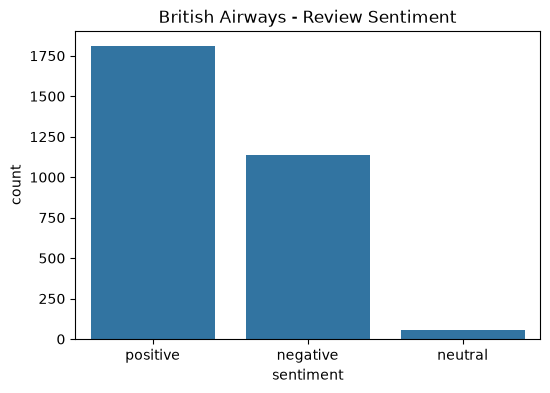

In [14]:
plt.figure(figsize=(6,4))
sns.countplot(x="sentiment",data=df, order=["positive","negative","neutral"])
plt.title("British Airways - Review Sentiment")
plt.show()

## Sentiment Analysis

In [15]:
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score, classification_report

In [16]:
X = df["cleaned"]
y = df["sentiment"]

In [17]:
# turn text to numbers
tfidf = TfidfVectorizer(max_features=5000)
X_tfidf = tfidf.fit_transform(X)

In [18]:
# split train / test
X_train, X_test, y_train, y_test =train_test_split(X_tfidf, y, test_size=0.2, random_state=42)

In [19]:
log_reg = LogisticRegression()
log_reg.fit(X_train, y_train)

,"penalty penalty: {'l1', 'l2', 'elasticnet', None}, default='l2'Specify the norm of the penalty:- `None`: no penalty is added;- `'l2'`: add an L2 penalty term and it is the default choice;- `'l1'`: add an L1 penalty term;- `'elasticnet'`: both L1 and L2 penalty terms are added... warning:: Some penalties may not work with some solvers. See the parameter `solver` below, to know the compatibility between the penalty and solver... versionadded:: 0.19 l1 penalty with SAGA solver (allowing 'multinomial' + L1).. deprecated:: 1.8 `penalty` was deprecated in version 1.8 and will be removed in 1.10. Use `l1_ratio` and `C` instead. `l1_ratio=0` for `penalty='l2'`, `l1_ratio=1` for `penalty='l1'`, `l1_ratio` set to any float between 0 and 1 for `penalty='elasticnet'`, and `C=np.inf` for `penalty=None`.",'deprecated'
,"C C: float, default=1.0Inverse of regularization strength; must be a positive float.Like in support vector machines, smaller values specify strongerregularization. `C=np.inf` results in unpenalized logistic regression.For a visual example on the effect of tuning the `C` parameterwith an L1 penalty, see::ref:`sphx_glr_auto_examples_linear_model_plot_logistic_path.py`.",1.0
,"l1_ratio l1_ratio: float, default=0.0The Elastic-Net mixing parameter, with `0 <= l1_ratio <= 1`. Setting`l1_ratio=1` gives a pure L1-penalty, setting `l1_ratio=0` a pure L2-penalty.Any value between 0 and 1 gives an Elastic-Net penalty of the form`l1_ratio * L1 + (1 - l1_ratio) * L2`... warning:: Certain values of `l1_ratio`, i.e. some penalties, may not work with some solvers. See the parameter `solver` below, to know the compatibility between the penalty and solver... versionchanged:: 1.8 Default value changed from None to 0.0... deprecated:: 1.8 `None` is deprecated and will be removed in version 1.10. Always use `l1_ratio` to specify the penalty type.",0.0
,"dual dual: bool, default=FalseDual (constrained) or primal (regularized, see also:ref:`this equation <regularized-logistic-loss>`) formulation. Dual formulationis only implemented for l2 penalty with liblinear solver. Prefer `dual=False`when n_samples > n_features.",False
,"tol tol: float, default=1e-4Tolerance for stopping criteria.",0.0001
,"fit_intercept fit_intercept: bool, default=TrueSpecifies if a constant (a.k.a. bias or intercept) should beadded to the decision function.",True
,"intercept_scaling intercept_scaling: float, default=1Useful only when the solver `liblinear` is usedand `self.fit_intercept` is set to `True`. In this case, `x` becomes`[x, self.intercept_scaling]`,i.e. a ""synthetic"" feature with constant value equal to`intercept_scaling` is appended to the instance vector.The intercept becomes``intercept_scaling * synthetic_feature_weight``... note:: The synthetic feature weight is subject to L1 or L2 regularization as all other features. To lessen the effect of regularization on synthetic feature weight (and therefore on the intercept) `intercept_scaling` has to be increased.",1
,"class_weight class_weight: dict or 'balanced', default=NoneWeights associated with classes in the form ``{class_label: weight}``.If not given, all classes are supposed to have weight one.The ""balanced"" mode uses the values of y to automatically adjustweights inversely proportional to class frequencies in the input dataas ``n_samples / (n_classes * np.bincount(y))``.Note that these weights will be multiplied with sample_weight (passedthrough the fit method) if sample_weight is specified... versionadded:: 0.17 *class_weight='balanced'*",None
,"random_state random_state: int, RandomState instance, default=NoneUsed when ``solver`` == 'sag', 'saga' or 'liblinear' to shuffle thedata. See :term:`Glossary <random_state>` for details.",None
,"solver solver: {'lbfgs', 'liblinear', 'newton-cg', 'newton-cholesky', 'sag', 'saga'}, default='lbfgs'Algorithm to use in the optimization problem. Default is 'lbfgs'.To choose a solver, you might want to consider the following aspects:- 'lbfgs' is a good default sol

              precision    recall  f1-score   support

    negative       0.81      0.76      0.78       238
     neutral       0.00      0.00      0.00        12
    positive       0.83      0.89      0.86       350

    accuracy                           0.82       600
   macro avg       0.55      0.55      0.55       600
weighted avg       0.80      0.82      0.81       600



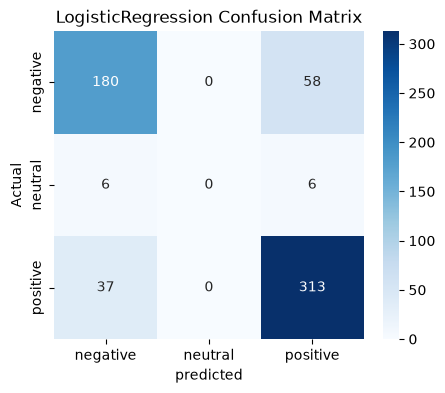

In [20]:
from sklearn.metrics import confusion_matrix
pred = log_reg.predict(X_test)
print(classification_report(y_test, pred, zero_division=0))

cm = confusion_matrix(y_test, pred)

plt.figure(figsize=(5, 4))
sns.heatmap(cm, annot=True, fmt="d", cmap="Blues",
            xticklabels=["negative", "neutral", "positive"],
            yticklabels=["negative", "neutral", "positive"])
plt.xlabel("predicted")
plt.ylabel("Actual")
plt.title("LogisticRegression Confusion Matrix")
plt.show()

In [21]:
from sklearn.naive_bayes import MultinomialNB
mult_nb = MultinomialNB()
mult_nb.fit(X_train, y_train)

,"alpha alpha: float or array-like of shape (n_features,), default=1.0Additive (Laplace/Lidstone) smoothing parameter(set alpha=0 and force_alpha=True, for no smoothing).",1.0
,"force_alpha force_alpha: bool, default=TrueIf False and alpha is less than 1e-10, it will set alpha to1e-10. If True, alpha will remain unchanged. This may causenumerical errors if alpha is too close to 0... versionadded:: 1.2.. versionchanged:: 1.4 The default value of `force_alpha` changed to `True`.",True
,"fit_prior fit_prior: bool, default=TrueWhether to learn class prior probabilities or not.If false, a uniform prior will be used.",True
,"class_prior class_prior: array-like of shape (n_classes,), default=NonePrior probabilities of the classes. If specified, the priors are notadjusted according to the data.",None
Name,Type,Value
"class_count_ class_count_: ndarray of shape (n_classes,)Number of samples encountered for each class during fitting. Thisvalue is weighted by the sample weight when provided.","ndarray[float64](3,)","[ 896., 42.,1462.]"
"class_log_prior_ class_log_prior_: ndarray of shape (n_classes,)Smoothed empirical log probability for each class.","ndarray[float64](3,)","[-0.99,-4.05,-0.5 ]"
"classes_ classes_: ndarray of shape (n_classes,)Class labels known to the classifier","ndarray[<U8](3,)","['negative','neutral','positive']"
"feature_count_ feature_count_: ndarray of shape (n_classes, n_features)Number of samples encountered for each (class, feature)during fitting. This value is weighted by the sample weight whenprovided.","ndarray[float64](3, 5000)","[[0.14,0.78,0.78,...,0.27,0.18,2.66], [0. ,0. ,0. ,...,0. ,0. ,0. ], [0.18,0.52,1.22,...,0.8 ,0.22,1.59]]"
"feature_log_prob_ feature_log_prob_: ndarray of shape (n_classes, n_features)Empirical log probability of featuresgiven a class, ``P(x_i|y)``.","ndarray[float64](3, 5000)","[[-9.17,-8.73,-8.72,...,-9.06,-9.13,-8. ], [-8.57,-8.57,-8.57,...,-8.57,-8.57,-8.57], [-9.45,-9.2 ,-8.82,...,-9.03,-9.42,-8.67]]"
n_features_in_ n_features_in_: intNumber of features seen during :term:`fit`... versionadded:: 0.24,int,5000


              precision    recall  f1-score   support

    negative       0.75      0.45      0.56       238
     neutral       0.00      0.00      0.00        12
    positive       0.69      0.91      0.79       350

    accuracy                           0.71       600
   macro avg       0.48      0.45      0.45       600
weighted avg       0.70      0.71      0.68       600



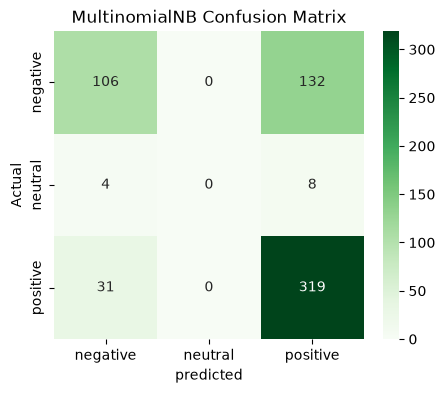

In [22]:
from sklearn.metrics import confusion_matrix
pred = mult_nb.predict(X_test)
print(classification_report(y_test, pred, zero_division=0))

cm = confusion_matrix(y_test, pred)

plt.figure(figsize=(5, 4))
sns.heatmap(cm, annot=True, fmt="d", cmap="Greens",
            xticklabels=["negative", "neutral", "positive"],
            yticklabels=["negative", "neutral", "positive"])
plt.xlabel("predicted")
plt.ylabel("Actual")
plt.title("MultinomialNB Confusion Matrix")
plt.show()

In [23]:
from sklearn.svm import SVC, LinearSVC
svc_model = SVC()
svc_model.fit(X_train, y_train)

,"C C: float, default=1.0Regularization parameter. The strength of the regularization isinversely proportional to C. Must be strictly positive. The penaltyis a squared l2 penalty. For an intuitive visualization of the effectsof scaling the regularization parameter C, see:ref:`sphx_glr_auto_examples_svm_plot_svm_scale_c.py`.",1.0
,"kernel kernel: {'linear', 'poly', 'rbf', 'sigmoid', 'precomputed'} or callable, default='rbf'Specifies the kernel type to be used in the algorithm. Ifnone is given, 'rbf' will be used. If a callable is given it is used topre-compute the kernel matrix from data matrices; that matrix should bean array of shape ``(n_samples, n_samples)``. For an intuitivevisualization of different kernel types see:ref:`sphx_glr_auto_examples_svm_plot_svm_kernels.py`.",'rbf'
,"degree degree: int, default=3Degree of the polynomial kernel function ('poly').Must be non-negative. Ignored by all other kernels.",3
,"gamma gamma: {'scale', 'auto'} or float, default='scale'Kernel coefficient for 'rbf', 'poly' and 'sigmoid'.- if ``gamma='scale'`` (default) is passed then it uses 1 / (n_features * X.var()) as value of gamma,- if 'auto', uses 1 / n_features- if float, must be non-negative... versionchanged:: 0.22 The default value of ``gamma`` changed from 'auto' to 'scale'.",'scale'
,"coef0 coef0: float, default=0.0Independent term in kernel function.It is only significant in 'poly' and 'sigmoid'.",0.0
,"shrinking shrinking: bool, default=TrueWhether to use the shrinking heuristic.See the :ref:`User Guide <shrinking_svm>`.",True
,"probability probability: bool, default=FalseWhether to enable probability estimates. This must be enabled priorto calling `fit`, will slow down that method as it internally uses5-fold cross-validation, and `predict_proba` may be inconsistent with`predict`. Read more in the :ref:`User Guide <scores_probabilities>`...deprecated:: 1.9 The `probability` parameter is deprecated and will be removed in 1.11. Use `CalibratedClassifierCV(SVC(), ensemble=False)` instead of `SVC(probability=True)`.",'deprecated'
,"tol tol: float, default=1e-3Tolerance for stopping criterion.",0.001
,"cache_size cache_size: float, default=200Specify the size of the kernel cache (in MB).",200
,"class_weight class_weight: dict or 'balanced', default=NoneSet the parameter C of class i to class_weight[i]*C forSVC. If not given, all classes are supposed to haveweight one.The ""balanced"" mode uses the values of y to automatically adjustweights inversely proportional to class frequencies in the input dataas ``n_samples / (n_classes * np.bincount(y))``.",None
,"verbose verbose: bool, default=FalseEnable verbose output. Note that this setting takes advantage of aper-process runtime setting in libsvm that, if enabled, may not workproperly in a multithreaded context.",False


              precision    recall  f1-score   support

    negative       0.80      0.74      0.77       238
     neutral       0.00      0.00      0.00        12
    positive       0.82      0.89      0.85       350

    accuracy                           0.81       600
   macro avg       0.54      0.54      0.54       600
weighted avg       0.80      0.81      0.80       600



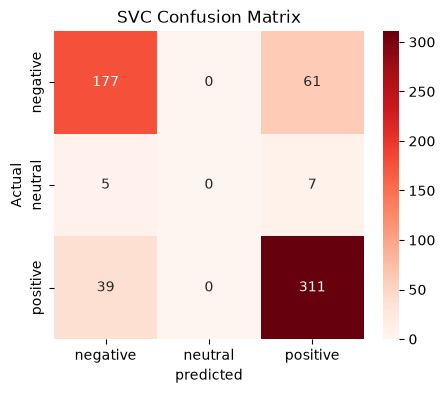

In [24]:
from sklearn.metrics import confusion_matrix
pred = svc_model.predict(X_test)
print(classification_report(y_test, pred, zero_division=0))

cm = confusion_matrix(y_test, pred)

plt.figure(figsize=(5, 4))
sns.heatmap(cm, annot=True, fmt="d", cmap="Reds",
            xticklabels=["negative", "neutral", "positive"],
            yticklabels=["negative", "neutral", "positive"])
plt.xlabel("predicted")
plt.ylabel("Actual")
plt.title("SVC Confusion Matrix")
plt.show()

In [25]:
lin_svc = LinearSVC()
lin_svc.fit(X_train, y_train)
df = df[df["sentiment"] !="neutral"]
df["sentiment"].value_counts()

sentiment
positive    1812
negative    1134
Name: count, dtype: int64

              precision    recall  f1-score   support

    negative       0.78      0.76      0.77       238
     neutral       0.00      0.00      0.00        12
    positive       0.83      0.87      0.85       350

    accuracy                           0.81       600
   macro avg       0.54      0.54      0.54       600
weighted avg       0.79      0.81      0.80       600



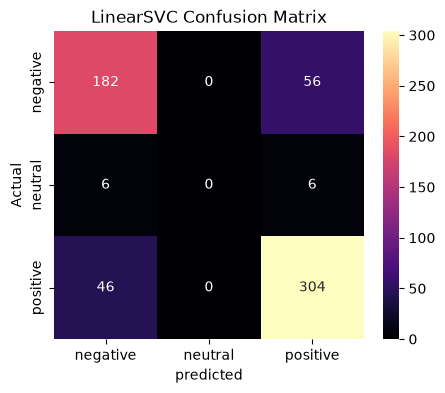

In [26]:
from sklearn.metrics import confusion_matrix
pred = lin_svc.predict(X_test)
print(classification_report(y_test, pred, zero_division=0))

cm = confusion_matrix(y_test, pred)

plt.figure(figsize=(5, 4))
sns.heatmap(cm, annot=True, fmt="d", cmap="magma",
            xticklabels=["negative", "neutral", "positive"],
            yticklabels=["negative", "neutral", "positive"])
plt.xlabel("predicted")
plt.ylabel("Actual")
plt.title("LinearSVC Confusion Matrix")
plt.show()

In [27]:
from sklearn.pipeline import Pipeline
from sklearn.feature_extraction.text import TfidfVectorizer

In [28]:
pipe = Pipeline([
    ("tfidf", TfidfVectorizer(max_features=5000)),
    ("log_model", LogisticRegression(class_weight="balanced", max_iter=1000))
])

In [29]:
pipe.fit(df["cleaned"], df["sentiment"])

,"steps steps: list of tuplesList of (name of step, estimator) tuples that are to be chained insequential order. To be compatible with the scikit-learn API, all stepsmust define `fit`. All non-last steps must also define `transform`. See:ref:`Combining Estimators <combining_estimators>` for more details.","[('tfidf', ...), ('log_model', ...)]"
,"transform_input transform_input: list of str, default=NoneThe names of the :term:`metadata` parameters that should be transformed by thepipeline before passing it to the step consuming it.This enables transforming some input arguments to ``fit`` (other than ``X``)to be transformed by the steps of the pipeline up to the step which requiresthem. Requirement is defined via :ref:`metadata routing <metadata_routing>`.For instance, this can be used to pass a validation set through the pipeline.You can only set this if metadata routing is enabled, which youcan enable using ``sklearn.set_config(enable_metadata_routing=True)``... versionadded:: 1.6",None
,"memory memory: str or object with the joblib.Memory interface, default=NoneUsed to cache the fitted transformers of the pipeline. The last stepwill never be cached, even if it is a transformer. By default, nocaching is performed. If a string is given, it is the path to thecaching directory. Enabling caching triggers a clone of the transformersbefore fitting. Therefore, the transformer instance given to thepipeline cannot be inspected directly. Use the attribute ``named_steps``or ``steps`` to inspect estimators within the pipeline. Caching thetransformers is advantageous when fitting is time consuming. See:ref:`sphx_glr_auto_examples_neighbors_plot_caching_nearest_neighbors.py`for an example on how to enable caching.",None
,"verbose verbose: bool, default=FalseIf True, the time elapsed while fitting each step will be printed as itis completed.",False
Name,Type,Value
"classes_ classes_: ndarray of shape (n_classes,)The classes labels. Only exist if the last step of the pipeline is aclassifier.","ndarray[object](2,)","['negative','positive']"
,"max_features max_features: int, default=NoneIf not None, build a vocabulary that only consider the top`max_features` ordered by term frequency across the corpus.Otherwise, all features are used.This parameter is ignored if vocabulary is not None.",5000
,"input input: {'filename', 'file', 'content'}, default='content'- If `'filename'`, the sequence passed as an argument to fit is expected to be a list of filenames that need reading to fetch the raw content to analyze.- If `'file'`, the sequence items must have a 'read' method (file-like object) that is called to fetch the bytes in memory.- If `'content'`, the input is expected to be a sequence of items that can be of type string or byte.",'content'
,"encoding encoding: str, default='utf-8'If bytes or files are given to analyze, this encoding is used todecode.",'utf-8'
,"decode_error decode_error: {'strict', 'ignore', 'replace'}, default='strict'Instruction on what to do if a byte sequence is given to analyze thatcontains characters not of the given `encoding`. By default, it is'strict', meaning that a UnicodeDecodeError will be raised. Othervalues are 'ignore' and 'replace'.",'strict'
,"strip_accents strip_accents: {'ascii', 'unicode'} or callable, default=NoneRemove accents and perform other character normalizationduring the preprocessing step.'ascii' is a fast method that only works on characters that havea direct ASCII mapping.'unicode' is a slightly slower method that works on any characters.None (default) means no character normalization is performed.Both 'ascii' and 'unicode' use NFKD normalization from:func:`unicodedata.normalize`.",None


In [30]:
pipe.predict(["The flight was delayed and baggage lost"])

array(['negative'], dtype=object)

In [31]:
pipe.predict(["Amazing crew, love it"])

array(['positive'], dtype=object)

## Model Deployment

In [32]:
import joblib, os

In [33]:
joblib.dump(pipe, os.path.join(os.path.expanduser('~'), "Desktop", "sentiment_model.pkl"))
print("Model saved as sentiment_model")

Model saved as sentiment_model
